# 🧹 Notebook 2 — Data Cleaning & Preprocessing
**Goal:** Check and fix missing values, duplicates, data types, negative values, outliers, and encode categories.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/retail_store_inventory.csv')
print('Shape:', df.shape)
df.head()


Shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Step 1 — Basic Info Overview

In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

## Step 2 — Check for Null / Missing Values

In [3]:
null_count   = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({'Missing Count': null_count, 'Missing %': null_percent.round(2)})
missing_report = missing_report[missing_report['Missing Count'] > 0]

if missing_report.empty:
    print('✅ No missing values found!')
else:
    print(missing_report)
    missing_report['Missing %'].sort_values().plot(kind='barh', color='tomato', figsize=(10,5))
    plt.title('Missing Values by Column (%)')
    plt.show()


✅ No missing values found!


## Step 3 — Visualize Missing Values as Heatmap

In [4]:
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(14, 5))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Missing Value Heatmap (yellow = missing)')
    plt.show()
else:
    print('No missing values to visualize.')


No missing values to visualize.


## Step 4 — Handle Missing Values

In [5]:
# Numerical → fill with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled {col} with median')

# Categorical → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'  Filled {col} with mode')

print('Remaining missing values:', df.isnull().sum().sum())


Remaining missing values: 0


## Step 5 & 6 — Check and Remove Duplicate Rows

In [6]:
total_duplicates = df.duplicated().sum()
print(f'Duplicate rows found: {total_duplicates}')

before = len(df)
df.drop_duplicates(inplace=True)
print(f'Rows before: {before:,}  →  Rows after: {len(df):,}')


Duplicate rows found: 0
Rows before: 73,100  →  Rows after: 73,100


## Step 7 — Fix Data Types

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

numeric_cols = ['Inventory Level', 'Units Sold', 'Units Ordered',
                'Demand Forecast', 'Price', 'Discount',
                'Competitor Pricing', 'Holiday/Promotion']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Data types after fixing:')
print(df.dtypes)


Data types after fixing:
Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition             object
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                   object
dtype: object


## Step 8 — Check for Negative Values

In [8]:
cols_to_check = ['Units Sold', 'Units Ordered', 'Inventory Level', 'Price', 'Discount']
found = False
for col in cols_to_check:
    n = (df[col] < 0).sum()
    if n > 0:
        print(f'⚠️  {col} has {n} negative values — fixing...')
        df[col] = df[col].clip(lower=0)
        found = True
if not found:
    print('✅ No negative values found!')


✅ No negative values found!


## Step 9 & 10 — Detect and Visualize Outliers (IQR Method)

         Column  Lower Bound  Upper Bound  Outlier Count  Outlier %
     Units Sold      -182.00       434.00            715       0.98
Inventory Level      -175.50       724.50              0       0.00
  Units Ordered       -70.00       290.00              0       0.00
          Price       -35.16       145.68              0       0.00


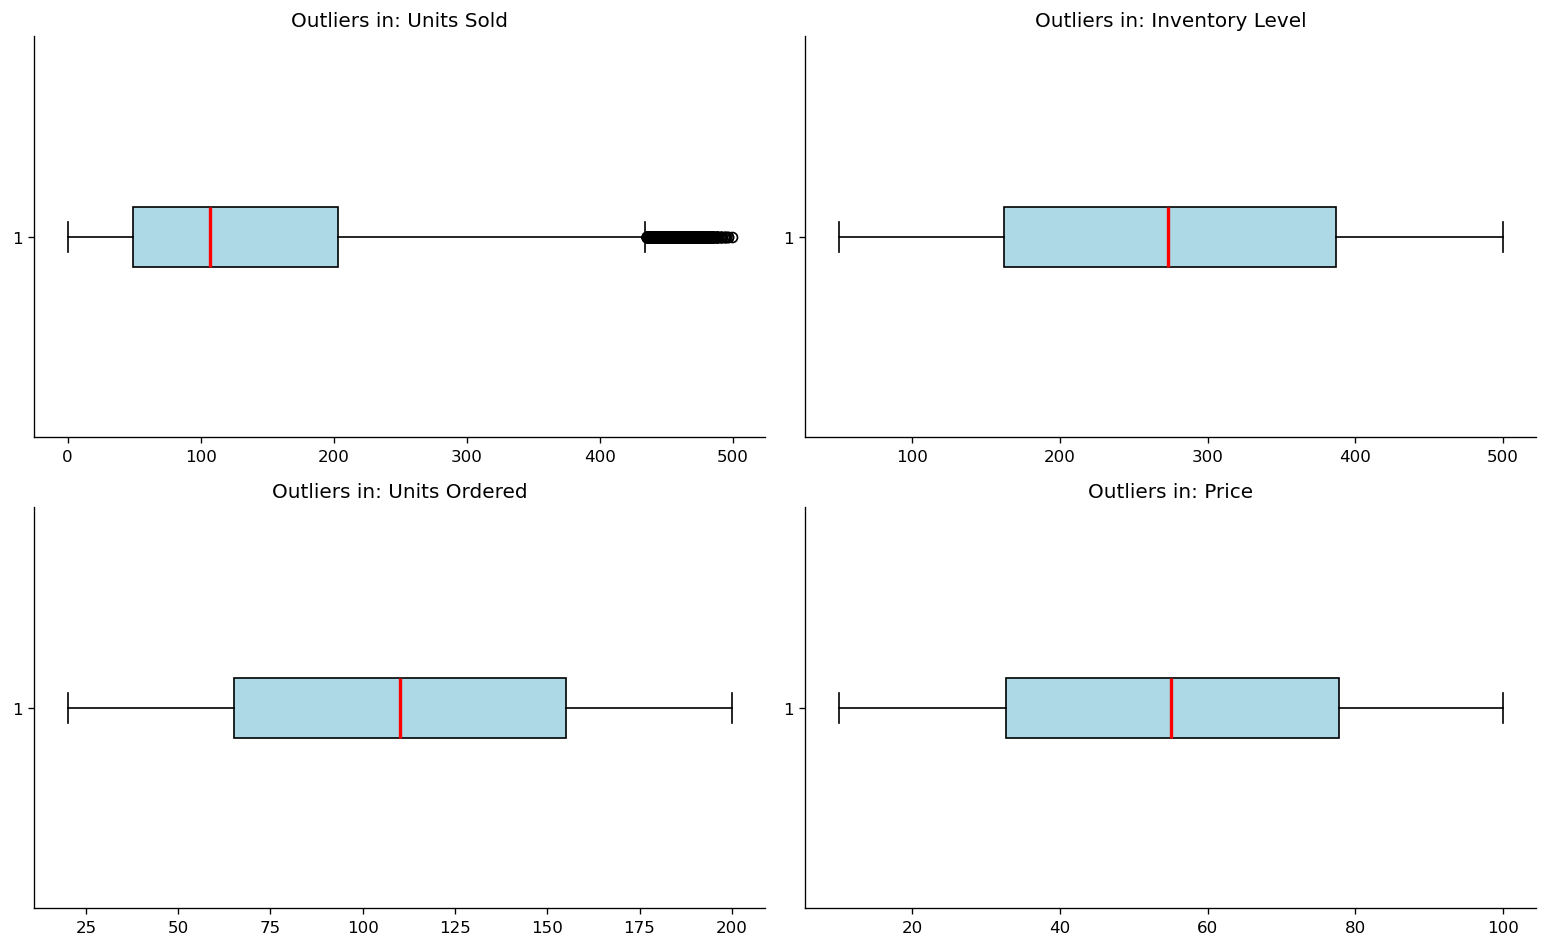

In [9]:
outlier_report = []
for col in ['Units Sold', 'Inventory Level', 'Units Ordered', 'Price']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'Column': col, 'Lower Bound': round(lower,2),
                           'Upper Bound': round(upper,2), 'Outlier Count': n_out,
                           'Outlier %': round(n_out/len(df)*100, 2)})

print(pd.DataFrame(outlier_report).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flatten(), ['Units Sold', 'Inventory Level', 'Units Ordered', 'Price']):
    ax.boxplot(df[col], vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Outliers in: {col}')
plt.tight_layout()
plt.savefig('../outputs/plots/outlier_boxplots.png')
plt.show()


## Step 11 — Cap Outliers (Winsorization)

In [10]:
for col in ['Units Sold', 'Inventory Level', 'Units Ordered', 'Price']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
    print(f'  Capped {col}: range now [{df[col].min():.1f}, {df[col].max():.1f}]')


  Capped Units Sold: range now [0.0, 434.0]
  Capped Inventory Level: range now [50.0, 500.0]
  Capped Units Ordered: range now [20.0, 200.0]
  Capped Price: range now [10.0, 100.0]


## Step 12 & 13 — Fix Inconsistent Text in Categorical Columns

In [11]:
for col in ['Category', 'Region', 'Weather Condition', 'Seasonality']:
    df[col] = df[col].str.strip().str.title()
    print(f'{col}: {df[col].unique().tolist()}')


Category: ['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing']
Region: ['North', 'South', 'West', 'East']
Weather Condition: ['Rainy', 'Sunny', 'Cloudy', 'Snowy']
Seasonality: ['Autumn', 'Summer', 'Winter', 'Spring']


## Step 14 — Extract Date Features

In [12]:
df['Year']      = df['Date'].dt.year
df['Month']     = df['Date'].dt.month
df['Week']      = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter']   = df['Date'].dt.quarter
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

print('Date features added:')
df[['Date','Year','Month','Week','DayOfWeek','Quarter','IsWeekend']].head()


Date features added:


,Date,Year,Month,Week,DayOfWeek,Quarter,IsWeekend
0,2022-01-01,2022,1,52,5,1,1
1,2022-01-01,2022,1,52,5,1,1
2,2022-01-01,2022,1,52,5,1,1
3,2022-01-01,2022,1,52,5,1,1
4,2022-01-01,2022,1,52,5,1,1


## Step 15 — Encode Categorical Columns

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['Category', 'Region', 'Weather Condition', 'Seasonality']:
    new_col = col.replace(' ', '_') + '_enc'
    df[new_col] = le.fit_transform(df[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col}: {mapping}')


Category: {'Clothing': np.int64(0), 'Electronics': np.int64(1), 'Furniture': np.int64(2), 'Groceries': np.int64(3), 'Toys': np.int64(4)}
Region: {'East': np.int64(0), 'North': np.int64(1), 'South': np.int64(2), 'West': np.int64(3)}
Weather Condition: {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}
Seasonality: {'Autumn': np.int64(0), 'Spring': np.int64(1), 'Summer': np.int64(2), 'Winter': np.int64(3)}


## Step 16 — Business Rule Validation

In [14]:
print('='*50)
print('BUSINESS RULE VALIDATION')
print('='*50)
print(f'Units Sold > Inventory Level : {(df["Units Sold"] > df["Inventory Level"]).sum()} violations')
print(f'Price <= 0                   : {(df["Price"] <= 0).sum()} violations')
print(f'Discount > 100%              : {(df["Discount"] > 100).sum()} violations')
print(f'Holiday/Promo not 0 or 1     : {(~df["Holiday/Promotion"].isin([0,1])).sum()} violations')


BUSINESS RULE VALIDATION
Units Sold > Inventory Level : 0 violations
Price <= 0                   : 0 violations
Discount > 100%              : 0 violations
Holiday/Promo not 0 or 1     : 0 violations


## Step 17 — Final Summary & Save

In [15]:
print('='*50)
print('FINAL CLEANED DATASET')
print('='*50)
print(f'Rows            : {df.shape[0]:,}')
print(f'Columns         : {df.shape[1]}')
print(f'Missing Values  : {df.isnull().sum().sum()}')
print(f'Duplicate Rows  : {df.duplicated().sum()}')

df.to_csv('../data/cleaned_data.csv', index=False)
print('\n✅ Saved to ../data/cleaned_data.csv')


FINAL CLEANED DATASET
Rows            : 73,100
Columns         : 25
Missing Values  : 0
Duplicate Rows  : 0

✅ Saved to ../data/cleaned_data.csv
